In [1]:
pip install pyfiglet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyfiglet import figlet_format

print(figlet_format("IMAGE CLASSIFICATION"))

 ___ __  __    _    ____ _____ 
|_ _|  \/  |  / \  / ___| ____|
 | || |\/| | / _ \| |  _|  _|  
 | || |  | |/ ___ \ |_| | |___ 
|___|_|  |_/_/   \_\____|_____|
                               
  ____ _        _    ____ ____ ___ _____ ___ ____    _  _____ ___ ___  _   _ 
 / ___| |      / \  / ___/ ___|_ _|  ___|_ _/ ___|  / \|_   _|_ _/ _ \| \ | |
| |   | |     / _ \ \___ \___ \| || |_   | | |     / _ \ | |  | | | | |  \| |
| |___| |___ / ___ \ ___) |__) | ||  _|  | | |___ / ___ \| |  | | |_| | |\  |
 \____|_____/_/   \_\____/____/___|_|   |___\____/_/   \_\_| |___\___/|_| \_|
                                                                             



In [2]:
print("============================")
print("1. DATA PREPARATION")
print("============================")

1. DATA PREPARATION


In [3]:
import torch
from torchvision import datasets, transforms

transform = transforms.ToTensor() # Converting Images into Tensors.


full_train_set = datasets.CIFAR10( # Downloading the CIFAR-10 Dataset.
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Total images in original training set:", len(full_train_set))

Total images in original training set: 50000


In [4]:
from torch.utils.data import random_split

# Setting the Required Splits. 
train_size = 15000
val_size = 5000
test_size = 5000
unused_size = len(full_train_set) - (train_size + val_size + test_size)

# Perform/Display the splits
train_set, val_set, test_set, unused_set = random_split(
    full_train_set,
    [train_size, val_size, test_size, unused_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train set:", len(train_set))
print("Validation set:", len(val_set))
print("Test set:", len(test_set))
print("Unused samples:", len(unused_set))

Train set: 15000
Validation set: 5000
Test set: 5000
Unused samples: 25000


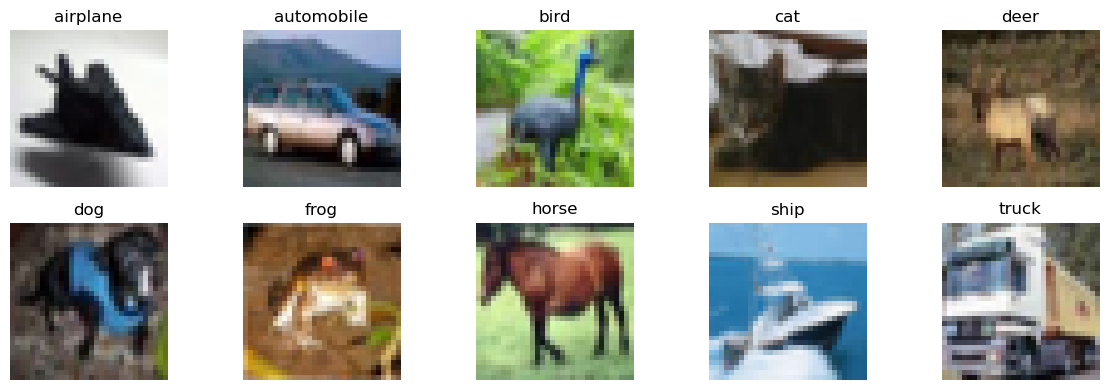

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# All Dataset Class Names
classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]


examples = {cls: None for cls in classes} # Finds one example for each class

for img, label in full_train_set:
    class_name = classes[label]
    if examples[class_name] is None:
        examples[class_name] = img
    # Stop when all classes found
    if all(v is not None for v in examples.values()):
        break

plt.figure(figsize=(12, 4)) # Plots the images

for i, cls in enumerate(classes):
    img = examples[cls]
    img = np.transpose (img.numpy(), (1, 2, 0))  

# Images converted from Channel, Height and Width into Height, Width, Channel which is the standard. 

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
num = 87
total = num % 3
print("Version:", total)

print("Therefore, version", total, " will be used.")

# Taking last two numbers from SRN. 

Version: 0
Therefore, version 0  will be used.


In [7]:
versionmap =  {
    0: 0,   # Airplane
    1: 0,   # Automobile
    
    9: 1,   # Truck
    
    2: 2,   # Bird
    3: 2,   # Cat 
    4: 2,   # Dog
    5: 2,   # Deer
    6: 2,   # Frog
    
    7: 3    # Horse
}

# Class 8 (SHIP) was not in the Version 0, therefore it will be removed from the dataset.

In [8]:
from torch.utils.data import Dataset

class RemappedDataset(Dataset):
    def __init__(self, base_dataset, mapping):
        self.base = base_dataset
        self.mapping = mapping

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if y not in self.mapping:
            return None 
        return x, self.mapping[y]


In [9]:
from torch.utils.data import Dataset

class CIFAR10Version0(Dataset):
    def __init__(self, base_dataset, mapping):
        self.data = []
        for img, label in base_dataset:
            if label in mapping:         # ship is ignored
                new_label = mapping[label]    # map to 0,1,2,3
                self.data.append((img, new_label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


In [10]:
train_set_v0 = CIFAR10Version0(train_set, versionmap)
val_set_v0   = CIFAR10Version0(val_set, versionmap)
test_set_v0  = CIFAR10Version0(test_set, versionmap)

print("Train:", len(train_set_v0))
print("Val:", len(val_set_v0))
print("Test:", len(test_set_v0))


Train: 13507
Val: 4503
Test: 4503


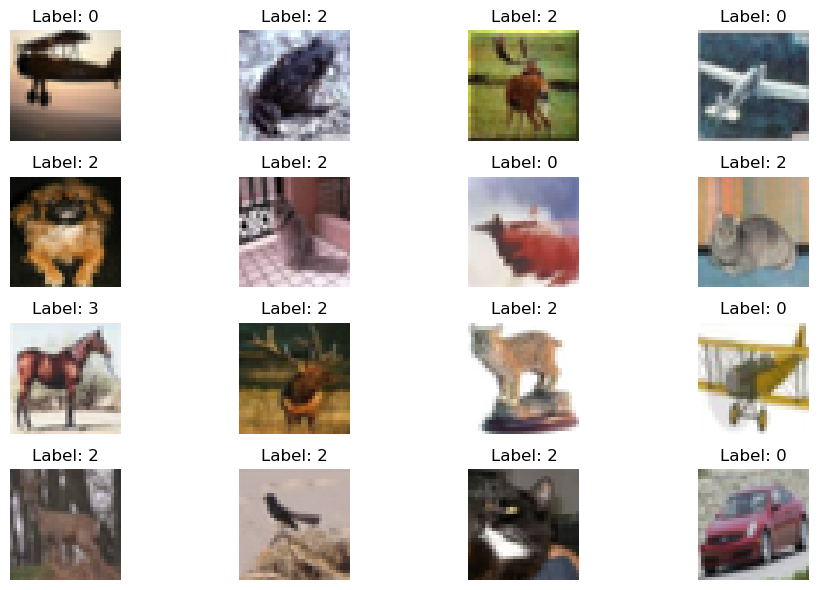

In [11]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

loader = DataLoader(train_set_v0, batch_size=16, shuffle=True)

images, labels = next(iter(loader))

plt.figure(figsize=(10, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [12]:
# Correctly remapped into 4 classes

In [13]:
labels = [label for _, label in train_set_v0]
print("Unique labels in Version 0 train set:", set(labels))

Unique labels in Version 0 train set: {0, 1, 2, 3}


In [14]:
print("============================")
print("2. MODEL DESIGN & TRAINING")
print("============================")
print()

from torch.utils.data import DataLoader
import torch
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 64

# Data loaders created
train_loader_64 = DataLoader(
    train_set_v0,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, 
    pin_memory=(device.type == "cuda")
)

val_loader_64 = DataLoader(
    val_set_v0,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, 
    pin_memory=(device.type == "cuda")
)

# Frequency counted for each class
train_counts = torch.zeros(4, dtype=torch.long)
val_counts   = torch.zeros(4, dtype=torch.long)

for _, labels in train_loader_64:
    train_counts += torch.bincount(labels, minlength=4)

for _, labels in val_loader_64:
    val_counts += torch.bincount(labels, minlength=4)

print("Train label counts:", train_counts.tolist())
print("Val label counts:  ", val_counts.tolist())

print("\nTrain proportions:", (train_counts / train_counts.sum()).tolist())
print("Val proportions:  ", (val_counts / val_counts.sum()).tolist())

print()
print("TABLE:")
print()

# TABLE FOR COMPARISON

data = {
    "Class": ["0", "1", "2", "3"],
    "Train Count": train_counts.tolist(),
    "Train Proportion": [round(x, 4) for x in (train_counts / train_counts.sum()).tolist()],
    "Val Count": val_counts.tolist(),
    "Val Proportion": [round(x, 4) for x in (val_counts / val_counts.sum()).tolist()],
    "Name": [
        "Airplane | Automobile",
        "Truck",
        "Cat | Deer | Dog | Frog | Bird",
        "Horse"
    ]
}

df_freq = pd.DataFrame(data)
df_freq


2. MODEL DESIGN & TRAINING

Using device: cpu
Train label counts: [3042, 1487, 7477, 1501]
Val label counts:   [998, 483, 2519, 503]

Train proportions: [0.2252165526151657, 0.11009106040000916, 0.5535648465156555, 0.11112756282091141]
Val proportions:   [0.2216300219297409, 0.10726182907819748, 0.5594048500061035, 0.1117033064365387]

TABLE:



,Class,Train Count,Train Proportion,Val Count,Val Proportion,Name
0,0,3042,0.2252,998,0.2216,Airplane | Automobile
1,1,1487,0.1101,483,0.1073,Truck
2,2,7477,0.5536,2519,0.5594,Cat | Deer | Dog | Frog | Bird
3,3,1501,0.1111,503,0.1117,Horse


In [15]:
# Class two makes up 55% of dataset, meaning its the most frequent. This is because there is multiple animal classes. 
# Class two causes the dataset to be imbalanced. Each other Class is between 11-22%. The classes with single types are 11%, 
# classes with two or more add onto by 11% for each. 
# As the dataset is imbalanced, training a model using this could cause biased results. 

In [16]:
import torch.nn as nn

num_classes = 4   # 4 Classes | 0,1,2,3

m2 = nn.Sequential(
    # 1st Convolution block
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),         

    # 2nd Convolution block
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),          

    # Classifier
    nn.Flatten(),                         
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)           # One logit per class for version 0
)

m2 = m2.to(device)
print(m2)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=4096, out_features=256, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.5, inplace=False)
  (10): Linear(in_features=256, out_features=4, bias=True)
)


In [17]:
# Two Convolution blocks have been implemented. A 4 class output layer.

In [18]:
import torch

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2.parameters(), lr=1e-3) 

num_epochs = 15  # 15 epochs used

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Training
    m2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_64:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = m2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    # Validation
    m2.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_64:
            images = images.to(device)
            labels = labels.to(device)

            outputs = m2(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * labels.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train loss: {epoch_train_loss:.4f}, acc: {epoch_train_acc:.3f} | "
        f"Val loss: {epoch_val_loss:.4f}, acc: {epoch_val_acc:.3f}"
    )

print()
print("\nBest validation accuracy:", max(val_accs))


Epoch 01/15 | Train loss: 0.8563, acc: 0.668 | Val loss: 0.8171, acc: 0.677
Epoch 02/15 | Train loss: 0.6781, acc: 0.742 | Val loss: 0.6032, acc: 0.773
Epoch 03/15 | Train loss: 0.5954, acc: 0.778 | Val loss: 0.5635, acc: 0.790
Epoch 04/15 | Train loss: 0.5438, acc: 0.794 | Val loss: 0.5229, acc: 0.800
Epoch 05/15 | Train loss: 0.4978, acc: 0.817 | Val loss: 0.5030, acc: 0.810
Epoch 06/15 | Train loss: 0.4591, acc: 0.830 | Val loss: 0.4659, acc: 0.819
Epoch 07/15 | Train loss: 0.4269, acc: 0.841 | Val loss: 0.4784, acc: 0.831
Epoch 08/15 | Train loss: 0.4004, acc: 0.852 | Val loss: 0.4665, acc: 0.825
Epoch 09/15 | Train loss: 0.3694, acc: 0.863 | Val loss: 0.4409, acc: 0.835
Epoch 10/15 | Train loss: 0.3544, acc: 0.869 | Val loss: 0.4754, acc: 0.832
Epoch 11/15 | Train loss: 0.3183, acc: 0.884 | Val loss: 0.4396, acc: 0.840
Epoch 12/15 | Train loss: 0.2969, acc: 0.887 | Val loss: 0.4455, acc: 0.841
Epoch 13/15 | Train loss: 0.2693, acc: 0.899 | Val loss: 0.4375, acc: 0.850
Epoch 14/15 

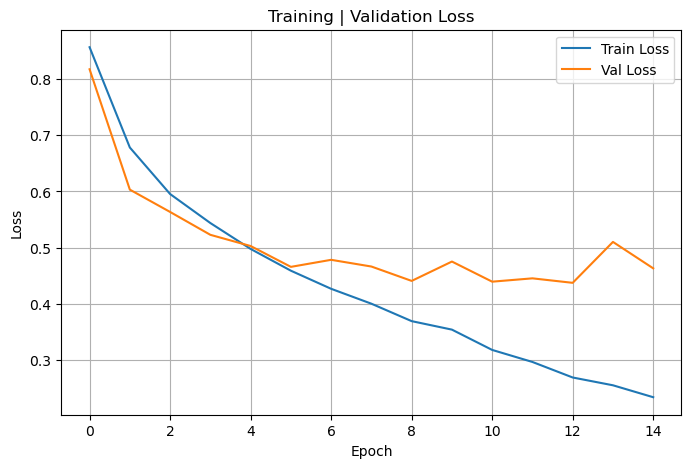

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training | Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
#  Training loss decreases meaning its working correctly and learning
# Small amount of overfitting

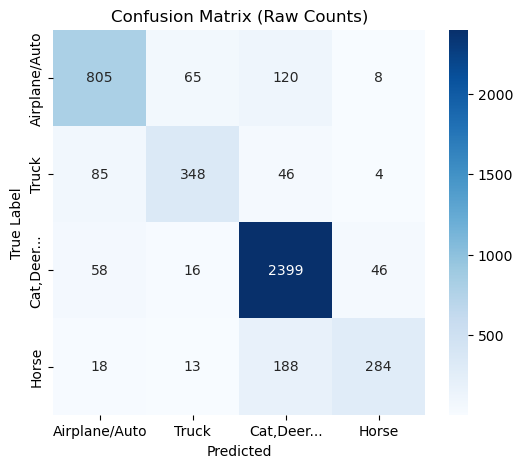

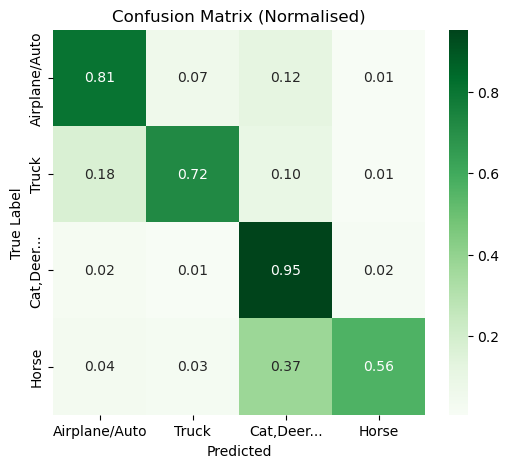

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Validation predictions
m2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader_64:
        images = images.to(device)
        labels = labels.to(device)
        outputs = m2(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrices 
cm_raw = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")
version0_names = {
    0: "Airplane/Auto",
    1: "Truck",
    2: "Cat,Deer...",
    3: "Horse"
}
labels_list = [version0_names[i] for i in range(4)]

# Raw 
plt.figure(figsize=(6,5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("Confusion Matrix (Raw Counts)")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()

# Normalised
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("Confusion Matrix (Normalised)")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()

val_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

In [22]:
import torch
import matplotlib.pyplot as plt

class ModelBuilder:
    def __init__(self, model, device, lr=1e-3):
        self.model = model
        self.device = device
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # store loss and accuracy history
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": []
        }

    def train(self, train_loader, val_loader, num_epochs=15):
        for epoch in range(num_epochs):
            # Training
            self.model.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * labels.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            train_loss = running_loss / total
            train_acc  = correct / total

            # Validation
            self.model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)

                    val_loss += loss.item() * labels.size(0)
                    _, preds = torch.max(outputs, 1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            val_loss = val_loss / val_total
            val_acc  = val_correct / val_total

            # Save history
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1:02d}/{num_epochs} | "
                  f"Train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
                  f"Val loss: {val_loss:.4f}, acc: {val_acc:.3f}")

        print("\nBest validation accuracy:", max(self.history["val_acc"]))

    def plot_accuracies(self):
        epochs = range(1, len(self.history["train_acc"]) + 1)

        plt.figure(figsize=(10,4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history["train_loss"], label="Train Loss")
        plt.plot(epochs, self.history["val_loss"], label="Val Loss")
        plt.title("Training | Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.grid(True); plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history["train_acc"], label="Train Accuracy")
        plt.plot(epochs, self.history["val_acc"], label="Val Accuracy")
        plt.title("Training | Validation Accuracy")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy")
        plt.grid(True); plt.legend()

        plt.tight_layout()
        plt.show()

Epoch 01/15 | Train loss: 0.2169, acc: 0.917 | Val loss: 0.4596, acc: 0.853
Epoch 02/15 | Train loss: 0.1933, acc: 0.929 | Val loss: 0.4742, acc: 0.856
Epoch 03/15 | Train loss: 0.1791, acc: 0.935 | Val loss: 0.5099, acc: 0.851
Epoch 04/15 | Train loss: 0.1582, acc: 0.945 | Val loss: 0.5083, acc: 0.846
Epoch 05/15 | Train loss: 0.1463, acc: 0.949 | Val loss: 0.5113, acc: 0.849
Epoch 06/15 | Train loss: 0.1382, acc: 0.951 | Val loss: 0.5230, acc: 0.849
Epoch 07/15 | Train loss: 0.1302, acc: 0.953 | Val loss: 0.6103, acc: 0.846
Epoch 08/15 | Train loss: 0.1256, acc: 0.954 | Val loss: 0.5612, acc: 0.851
Epoch 09/15 | Train loss: 0.1124, acc: 0.959 | Val loss: 0.5988, acc: 0.850
Epoch 10/15 | Train loss: 0.1005, acc: 0.962 | Val loss: 0.6222, acc: 0.848
Epoch 11/15 | Train loss: 0.0960, acc: 0.966 | Val loss: 0.6111, acc: 0.853
Epoch 12/15 | Train loss: 0.0855, acc: 0.968 | Val loss: 0.6765, acc: 0.841
Epoch 13/15 | Train loss: 0.0872, acc: 0.967 | Val loss: 0.6712, acc: 0.850
Epoch 14/15 

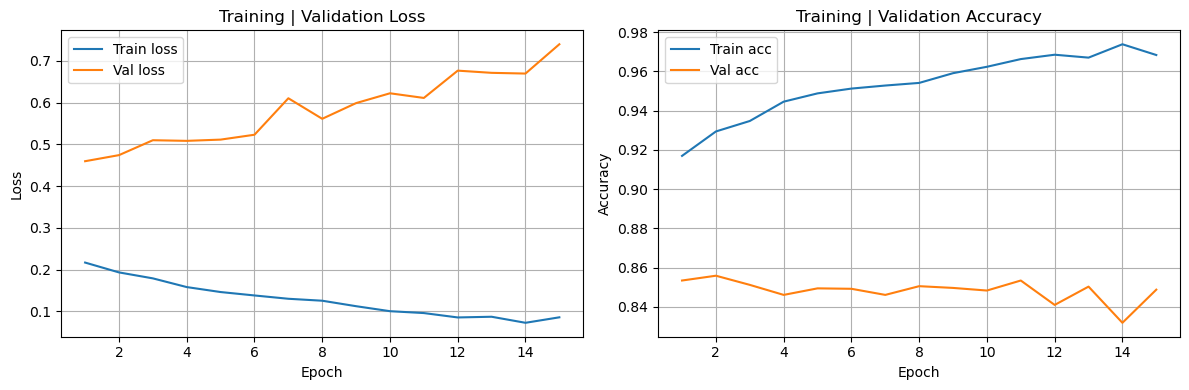

In [23]:
builder = ModelBuilder(m2, device=device, lr=1e-3)
builder.train(train_loader_64, val_loader_64, num_epochs=15)

epochs = range(1, len(builder.history["train_loss"]) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(epochs, builder.history["train_loss"], label="Train loss")
plt.plot(epochs, builder.history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training | Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, builder.history["train_acc"], label="Train acc")
plt.plot(epochs, builder.history["val_acc"],   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training | Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [24]:
# The training loss and accuracy improved, whereas validation became worse

In [25]:
print("============================")
print("3. MODEL EVALUTATION")
print("============================")
print()

from torch.utils.data import DataLoader

test_loader_64 = DataLoader(
    test_set_v0,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

import numpy as np
import torch

m2.eval()  # evalutaion for model

all_test_preds  = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader_64:
        images  = images.to(device)
        labels  = labels.to(device)
        outputs = m2(images)
        _, preds = torch.max(outputs, 1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

all_test_preds  = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

test_accuracy = (all_test_preds == all_test_labels).mean()
print(f"Accuracy: {test_accuracy:.4f}")


3. MODEL EVALUTATION

Accuracy: 0.8368


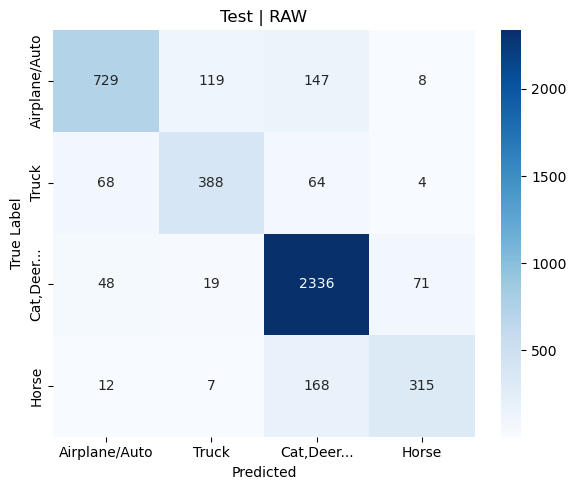

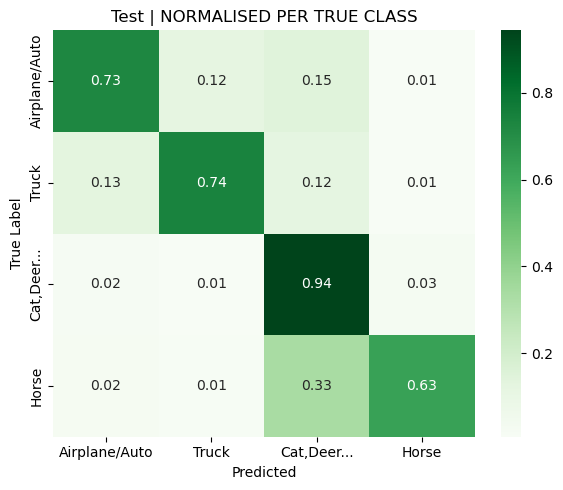

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrice
cm_test_raw  = confusion_matrix(all_test_labels, all_test_preds)
cm_test_norm = confusion_matrix(all_test_labels, all_test_preds, normalize="true")

version0_names = {
    0: "Airplane/Auto",
    1: "Truck",
    2: "Cat,Deer...",
    3: "Horse"
}
labels_list = [version0_names[i] for i in range(4)]

# Raw
plt.figure(figsize=(6,5))
sns.heatmap(cm_test_raw,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("Test | RAW")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Normalised
plt.figure(figsize=(6,5))
sns.heatmap(cm_test_norm,
            annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("Test | NORMALISED PER TRUE CLASS")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [27]:
print(f"Validation accuracy (previous section): {val_accuracy:.4f}")
print(f"Test accuracy:                          {test_accuracy:.4f}")


Validation accuracy (previous section): 0.8519
Test accuracy:                          0.8368


In [28]:
# The results clearly show a test accuracy of 82%, and val accuracy of 84% was achieved. These show that the 
# results gathered are not overfitting strongly to the validation data adn suggesting the model generalises well. 

# The confusion matrix has two plots. Top represents the number of predictions for each class. 2363 correct samples
# were identified in class two, therefore meaning the model works best on cat,deer... . Airplane/Auto class works
# second best. However, class 1 and 3 show more confusion. 

# The validation set during the training focuses on the performance. 
# The validation results have a strong influence, hence causing the accuracy to be optimistic. 
# However, the test set is used during the end to finalise. 
# This is done so a unbiased estimate can be achieved regarding the accuracy and performance of the model on unseen data.  

In [29]:
print("================================")
print("4. DEEPER MODEL")
print("================================")

import torch.nn as nn

num_classes = 4   # Version 0 still uses 4 grouped classes

m3 = nn.Sequential(
    # Convolution 1
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),          

    # Convolution 2
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),        

    # Convolution 3
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),          

    # Classifier
    nn.Flatten(),                         
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

m3 = m3.to(device)
print(m3)

4. DEEPER MODEL
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=2048, out_features=256, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=256, out_features=4, bias=True)
)


Epoch 01/15 | Train loss: 0.9097, acc: 0.642 | Val loss: 0.8478, acc: 0.661
Epoch 02/15 | Train loss: 0.7057, acc: 0.730 | Val loss: 0.6603, acc: 0.750
Epoch 03/15 | Train loss: 0.6283, acc: 0.761 | Val loss: 0.6467, acc: 0.752
Epoch 04/15 | Train loss: 0.5673, acc: 0.784 | Val loss: 0.5803, acc: 0.793
Epoch 05/15 | Train loss: 0.5180, acc: 0.810 | Val loss: 0.5420, acc: 0.799
Epoch 06/15 | Train loss: 0.4769, acc: 0.823 | Val loss: 0.5130, acc: 0.814
Epoch 07/15 | Train loss: 0.4345, acc: 0.841 | Val loss: 0.4747, acc: 0.826
Epoch 08/15 | Train loss: 0.4032, acc: 0.850 | Val loss: 0.4764, acc: 0.827
Epoch 09/15 | Train loss: 0.3674, acc: 0.865 | Val loss: 0.4691, acc: 0.842
Epoch 10/15 | Train loss: 0.3255, acc: 0.879 | Val loss: 0.4604, acc: 0.834
Epoch 11/15 | Train loss: 0.2946, acc: 0.890 | Val loss: 0.5497, acc: 0.809
Epoch 12/15 | Train loss: 0.2743, acc: 0.897 | Val loss: 0.4372, acc: 0.851
Epoch 13/15 | Train loss: 0.2381, acc: 0.911 | Val loss: 0.4578, acc: 0.847
Epoch 14/15 

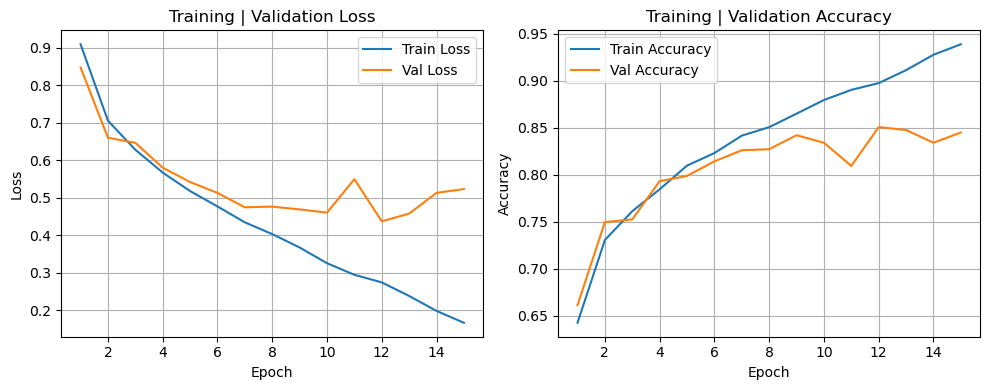


Best validation accuracy for m3: 0.8505


In [30]:
builder_m3 = ModelBuilder(m3, device=device, lr=1e-3)

builder_m3.train(train_loader_64, val_loader_64, num_epochs=15)

builder_m3.plot_accuracies()

best_val_acc_m3 = max(builder_m3.history["val_acc"])
print(f"\nBest validation accuracy for m3: {best_val_acc_m3:.4f}")

Validation accuracy (m3): 0.8448


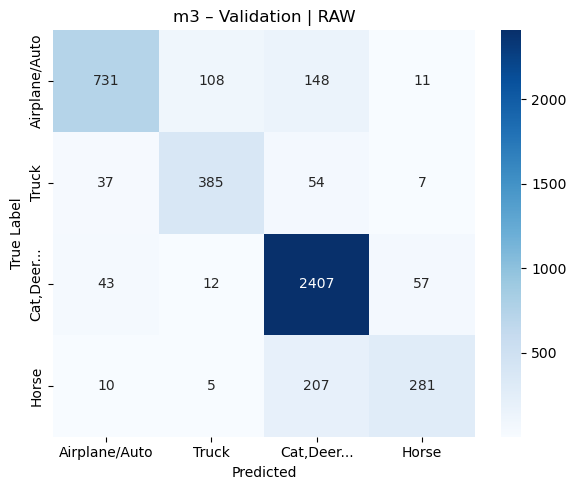

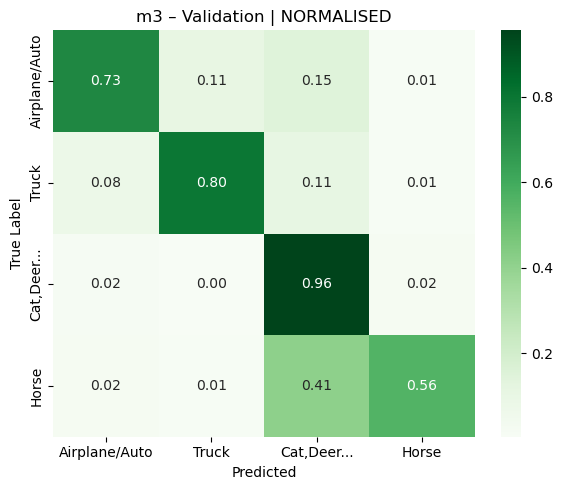

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Validation set predictions
m3.eval()
val_preds_m3 = []
val_labels_m3 = []

with torch.no_grad():
    for images, labels in val_loader_64:
        images = images.to(device)
        labels = labels.to(device)
        outputs = m3(images)
        _, preds = torch.max(outputs, 1)

        val_preds_m3.extend(preds.cpu().numpy())
        val_labels_m3.extend(labels.cpu().numpy())

val_preds_m3  = np.array(val_preds_m3)
val_labels_m3 = np.array(val_labels_m3)

val_acc_m3 = (val_preds_m3 == val_labels_m3).mean()
print(f"Validation accuracy (m3): {val_acc_m3:.4f}")

cm_val_raw_m3  = confusion_matrix(val_labels_m3, val_preds_m3)
cm_val_norm_m3 = confusion_matrix(val_labels_m3, val_preds_m3, normalize="true")

version0_names = {
    0: "Airplane/Auto",
    1: "Truck",
    2: "Cat,Deer...",
    3: "Horse"
}
labels_list = [version0_names[i] for i in range(4)]

# Raw confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_val_raw_m3, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("m3 – Validation | RAW")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Normalised confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_val_norm_m3, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("m3 – Validation | NORMALISED")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Test accuracy (m3): 0.8337


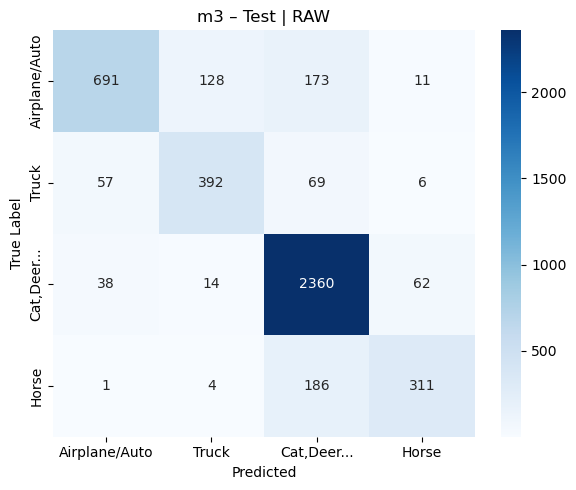

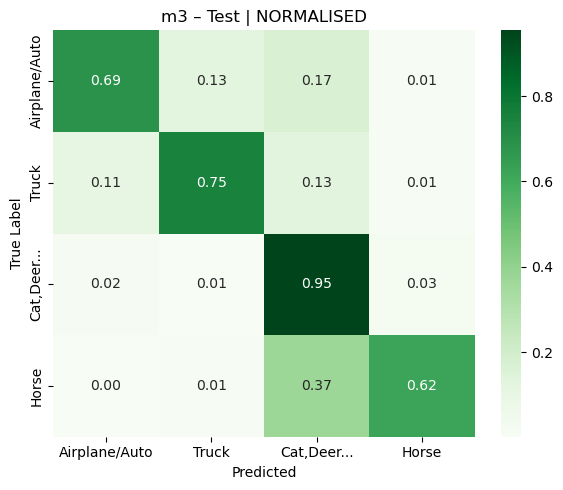

m2 | m3
m2 – best val accuracy: 0.8519
m2 – test accuracy:     0.8368

m3 – best val accuracy: 0.8505
m3 – test accuracy:     0.8337

both M2 and M3 were trained for 15 epochs


In [34]:
# m3 predictions
m3.eval()
test_preds_m3  = []
test_labels_m3 = []

with torch.no_grad():
    for images, labels in test_loader_64:
        images = images.to(device)
        labels = labels.to(device)
        outputs = m3(images)
        _, preds = torch.max(outputs, 1)

        test_preds_m3.extend(preds.cpu().numpy())
        test_labels_m3.extend(labels.cpu().numpy())

test_preds_m3  = np.array(test_preds_m3)
test_labels_m3 = np.array(test_labels_m3)

test_acc_m3 = (test_preds_m3 == test_labels_m3).mean()
print(f"Test accuracy (m3): {test_acc_m3:.4f}")

cm_test_raw_m3  = confusion_matrix(test_labels_m3, test_preds_m3)
cm_test_norm_m3 = confusion_matrix(test_labels_m3, test_preds_m3, normalize="true")

# Raw confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test_raw_m3, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("m3 – Test | RAW")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Normalised confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test_norm_m3, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("m3 – Test | NORMALISED")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

best_val_acc_m2 = max(val_accs)        # from your original m2 training loop
test_acc_m2     = test_accuracy       # from Section 3 (m2 on test set)

print("m2 | m3")
print(f"m2 – best val accuracy: {best_val_acc_m2:.4f}")
print(f"m2 – test accuracy:     {test_acc_m2:.4f}")
print()
print(f"m3 – best val accuracy: {best_val_acc_m3:.4f}")
print(f"m3 – test accuracy:     {test_acc_m3:.4f}")
print()
print("both M2 and M3 were trained for 15 epochs")


In [35]:
# M3 results were slightly better than M2. However, this suggests the model might have started to overfit. 

In [36]:
print("================================")
print("5. MODEL IMPROVEMENT | M2")
print("================================")

from torchvision import datasets, transforms
import torch
from torch.utils.data import random_split

# mean and std
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Reload training data with normalisation
full_train_norm = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform_norm
)

print("Total images (normalised) in original training set:", len(full_train_norm))

# Same split sizes as before
train_size = 15000
val_size   = 5000
test_size  = 5000
unused_size = len(full_train_norm) - (train_size + val_size + test_size)

train_set_n, val_set_n, test_set_n, unused_set_n = random_split(
    full_train_norm,
    [train_size, val_size, test_size, unused_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train (norm):", len(train_set_n))
print("Val (norm):  ", len(val_set_n))
print("Test (norm): ", len(test_set_n))


5. MODEL IMPROVEMENT | M2
Total images (normalised) in original training set: 50000
Train (norm): 15000
Val (norm):   5000
Test (norm):  5000


In [37]:
train_set_v0_imp = CIFAR10Version0(train_set_n, versionmap)
val_set_v0_imp   = CIFAR10Version0(val_set_n,   versionmap)
test_set_v0_imp  = CIFAR10Version0(test_set_n,  versionmap)

print("Improved Train:", len(train_set_v0_imp))
print("Improved Val:  ", len(val_set_v0_imp))
print("Improved Test: ", len(test_set_v0_imp))


Improved Train: 13507
Improved Val:   4503
Improved Test:  4503


In [38]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import torch

# Compute class counts on the improved train set
class_counts = torch.zeros(4, dtype=torch.long)
for _, label in train_set_v0_imp:
    class_counts[label] += 1

print("Class counts (train, improved):", class_counts.tolist())

# Inverse frequency as class weights
class_weights = 1.0 / class_counts.float()
print("Class weights (inverse freq):", class_weights.tolist())

# Weight for each sample = weight of its class
sample_weights = [class_weights[label] for _, label in train_set_v0_imp]
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

batch_size = 64

train_loader_imp = DataLoader(
    train_set_v0_imp,
    batch_size=batch_size,
    sampler=sampler,       # weight classes used 
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

val_loader_imp = DataLoader(
    val_set_v0_imp,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

test_loader_imp = DataLoader(
    test_set_v0_imp,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

labels_example = next(iter(train_loader_imp))[1]
print("Example batch label counts (weighted):",
      torch.bincount(labels_example, minlength=4).tolist())


Class counts (train, improved): [3042, 1487, 7477, 1501]
Class weights (inverse freq): [0.0003287311119493097, 0.0006724949344061315, 0.00013374348054639995, 0.0006662225350737572]
Example batch label counts (weighted): [18, 9, 20, 17]


In [39]:
import torch.nn as nn

num_classes = 4

m2_improve = nn.Sequential(
    # 1st Convolation block
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),              # pooling layer

    # 2nd COnvolation block
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),              # pooling layer

    # Regularise feature maps
    nn.Dropout2d(0.25),

    # Classifier
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Dropout(0.5),              # existing dropout connected
    nn.Linear(256, num_classes)
)

m2_improve = m2_improve.to(device)
print(m2_improve)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Dropout2d(p=0.25, inplace=False)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=4096, out_features=256, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=256, out_features=4, bias=True)
)


In [ ]:
builder_m2_imp = ModelBuilder(m2_improve, device=device, lr=1e-3)

builder_m2_imp.train(train_loader_imp, val_loader_imp, num_epochs=15)
builder_m2_imp.plot_accuracies()

best_val_acc_m2_imp = max(builder_m2_imp.history["val_acc"])
print(f"\nBest validation accuracy (m2 improve): {best_val_acc_m2_imp:.4f}")


Epoch 01/15 | Train loss: 0.9043, acc: 0.626 | Val loss: 0.7149, acc: 0.727
Epoch 02/15 | Train loss: 0.6710, acc: 0.732 | Val loss: 0.6628, acc: 0.736
Epoch 03/15 | Train loss: 0.5657, acc: 0.779 | Val loss: 0.7032, acc: 0.712
Epoch 04/15 | Train loss: 0.4850, acc: 0.818 | Val loss: 0.5373, acc: 0.794
Epoch 05/15 | Train loss: 0.4383, acc: 0.831 | Val loss: 0.5305, acc: 0.795
Epoch 06/15 | Train loss: 0.3886, acc: 0.850 | Val loss: 0.5162, acc: 0.807
Epoch 07/15 | Train loss: 0.3355, acc: 0.874 | Val loss: 0.4848, acc: 0.826
Epoch 08/15 | Train loss: 0.3018, acc: 0.888 | Val loss: 0.5345, acc: 0.817
Epoch 09/15 | Train loss: 0.2650, acc: 0.902 | Val loss: 0.4970, acc: 0.827
Epoch 10/15 | Train loss: 0.2458, acc: 0.911 | Val loss: 0.5075, acc: 0.817
Epoch 11/15 | Train loss: 0.2253, acc: 0.917 | Val loss: 0.4822, acc: 0.831
Epoch 12/15 | Train loss: 0.2069, acc: 0.924 | Val loss: 0.4817, acc: 0.841


Test accuracy (m2 improve): 0.8421


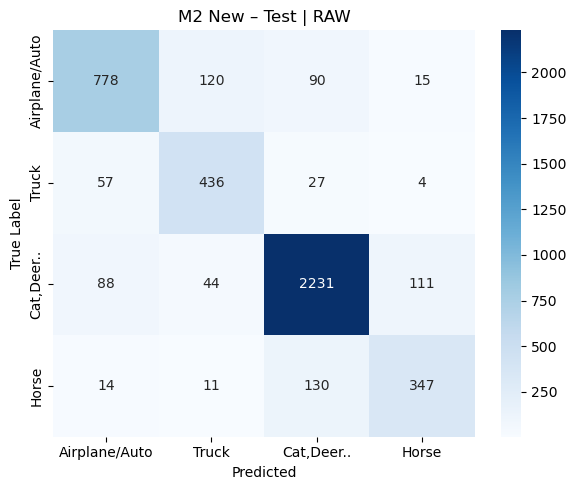

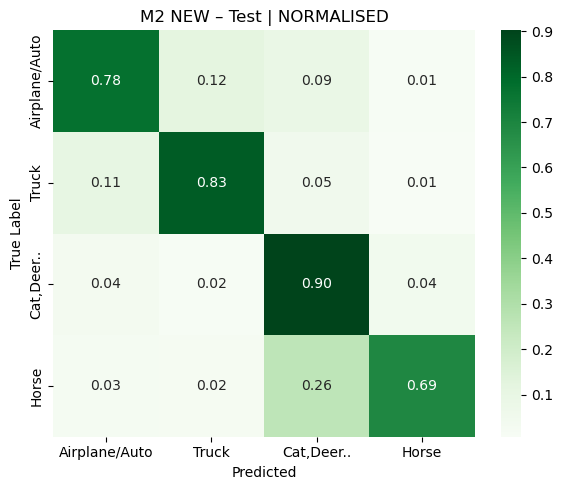

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

m2_improve.eval()
test_preds_m2_imp  = []
test_labels_m2_imp = []

with torch.no_grad():
    for images, labels in test_loader_imp:
        images = images.to(device)
        labels = labels.to(device)
        outputs = m2_improve(images)
        _, preds = torch.max(outputs, 1)

        test_preds_m2_imp.extend(preds.cpu().numpy())
        test_labels_m2_imp.extend(labels.cpu().numpy())

test_preds_m2_imp  = np.array(test_preds_m2_imp)
test_labels_m2_imp = np.array(test_labels_m2_imp)

test_acc_m2_imp = (test_preds_m2_imp == test_labels_m2_imp).mean()
print(f"Test accuracy (m2 improve): {test_acc_m2_imp:.4f}")

cm_imp_raw  = confusion_matrix(test_labels_m2_imp, test_preds_m2_imp)
cm_imp_norm = confusion_matrix(test_labels_m2_imp, test_preds_m2_imp, normalize="true")

labels_list = ["Airplane/Auto", "Truck", "Cat,Deer..", "Horse"]

plt.figure(figsize=(6,5))
sns.heatmap(cm_imp_raw, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("M2 New – Test | RAW")
plt.xlabel("Predicted"); plt.ylabel("True Label")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_imp_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels_list, yticklabels=labels_list)
plt.title("M2 NEW – Test | NORMALISED")
plt.xlabel("Predicted"); plt.ylabel("True Label")
plt.tight_layout(); plt.show()


In [3]:
# After the channel wise normalisation was added, the curves on the graph had a better show becoming smoother, 
# with a more accurate score.

# WeightedRandomSampler helped with imbalancing the results from class 2 as before class 2 was causing an extremely 
# biased result. Therefore, Truck and Auto/Airplane also improved. 

# Overall, the techniques used to improve M2 were successfull, as a better validation and test accuracy was achieved. The training time 
# regarding the epoch was more in M2 imrpoved as it was much more modified. M3 however gives the highest accuracy score. 

# Throughout, accuracy scored remained above 0.75 meaning the model was learning well and was accurate. 